# NVIDIA Nemotron — Exploratory Data Analysis

Goals:
1. Understand the distribution of problem types
2. Analyse answer patterns per type
3. Count few-shot examples per prompt
4. Inspect public test set

In [1]:
import sys
sys.path.insert(0, '..')  # allow importing src from notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import load_train, load_test, split_examples

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load data

In [2]:
train = load_train()
test  = load_test()
print('Train:', train.shape)
print('Test: ', test.shape)
train.head(5)

Train: (9500, 4)
Test:  (3, 3)


,id,prompt,answer,problem_type
0,00066667,"In Alice's Wonderland, a secret bit manipulati...",10010111,bit_manipulation
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati...",01000011,bit_manipulation
2,00189f6a,"In Alice's Wonderland, secret encryption rules...",cat imagines book,cipher
3,001b24c4,"In Alice's Wonderland, numbers are secretly co...",XXXVIII,bit_manipulation
4,001c63cb,"In Alice's Wonderland, secret encryption rules...",wizard creates secret,cipher


## 2. Problem type distribution

bit_manipulation    6778
symbol_transform    1555
cipher              1167
Name: problem_type, dtype: int64


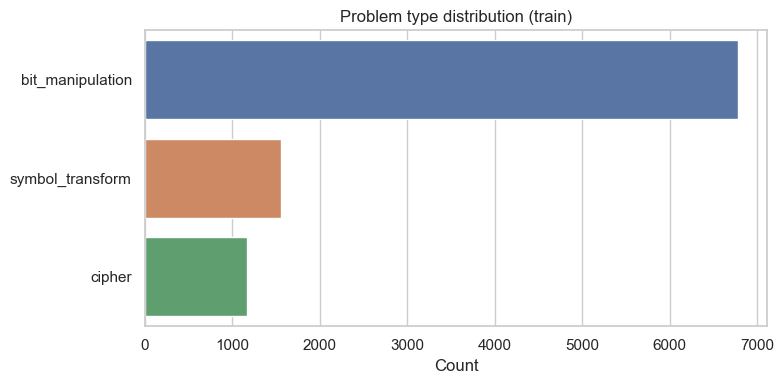

In [3]:
type_counts = train['problem_type'].value_counts()
print(type_counts)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=type_counts.values, y=type_counts.index, ax=ax)
ax.set_xlabel('Count')
ax.set_title('Problem type distribution (train)')
plt.tight_layout()
plt.show()

## 3. Answer analysis per type

In [4]:
train['answer_len'] = train['answer'].astype(str).str.len()
train['answer_is_numeric'] = pd.to_numeric(train['answer'], errors='coerce').notna()

print(train.groupby('problem_type')[['answer_len', 'answer_is_numeric']].agg(
    {'answer_len': ['mean', 'max'], 'answer_is_numeric': 'mean'}
))

                 answer_len     answer_is_numeric
                       mean max              mean
problem_type                                     
bit_manipulation   6.717026  37          0.707141
cipher            25.395030  39          0.000000
symbol_transform   2.943408   4          0.442444


## 4. Few-shot example count per prompt

                   count      mean       std  min  25%  50%  75%   max
problem_type                                                          
bit_manipulation  6778.0  3.415167  3.852139  0.0  0.0  3.0  5.0  11.0
cipher            1167.0  3.943445  0.811721  3.0  3.0  4.0  5.0   5.0
symbol_transform  1555.0  0.032797  0.185246  0.0  0.0  0.0  0.0   2.0


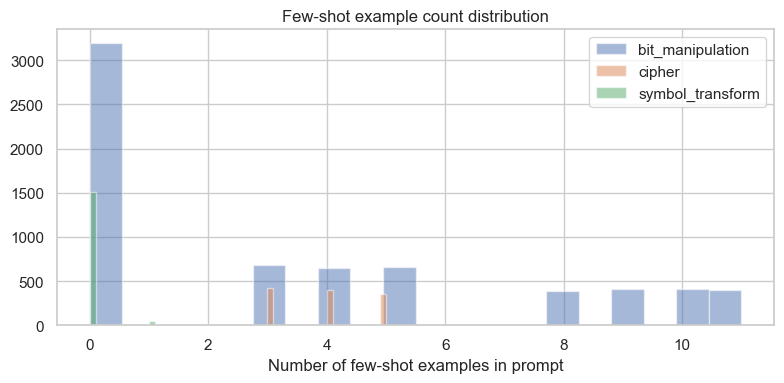

In [5]:
train['n_examples'] = train['prompt'].apply(lambda p: len(split_examples(p)))

print(train.groupby('problem_type')['n_examples'].describe())

fig, ax = plt.subplots(figsize=(8, 4))
for ptype, grp in train.groupby('problem_type'):
    grp['n_examples'].hist(ax=ax, alpha=0.5, label=ptype, bins=20)
ax.set_xlabel('Number of few-shot examples in prompt')
ax.set_title('Few-shot example count distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Prompt length distribution

In [6]:
train['prompt_len'] = train['prompt'].str.len()
print(train.groupby('problem_type')['prompt_len'].describe())

                   count        mean         std    min    25%    50%    75%  \
problem_type                                                                   
bit_manipulation  6778.0  314.629832  106.191747  197.0  222.0  284.0  424.0   
cipher            1167.0  367.095116   49.991907  265.0  324.0  365.0  408.0   
symbol_transform  1555.0  195.138264    9.782291  177.0  184.0  195.0  205.0   

                    max  
problem_type             
bit_manipulation  510.0  
cipher            485.0  
symbol_transform  212.0  


## 6. Test set preview

In [7]:
print('Test problem types:')
print(test['problem_type'].value_counts())
test[['id','problem_type','prompt']].head(10)

Test problem types:
bit_manipulation    2
cipher              1
Name: problem_type, dtype: int64


,id,problem_type,prompt
0,00066667,bit_manipulation,"In Alice's Wonderland, a secret bit manipulati..."
1,000b53cf,bit_manipulation,"In Alice's Wonderland, a secret bit manipulati..."
2,00189f6a,cipher,"In Alice's Wonderland, secret encryption rules..."


## 7. Key observations

- **Type distribution**: 3 types; 1.Bit Manipulation, 2.Symbol Transform, 3. Cipher

- **Answer types**: Based on what I observed, Bit Manipulation and Symbol Transformation type containt both string and numeric while Cipher types is all string
                answer_len     answer_is_numeric
                       mean max              mean
bit_manipulation   6.717026  37          0.707141
cipher            25.395030  39          0.000000
symbol_transform   2.943408   4          0.442444

- **Few-shot count**: Bit Manipulation 6,778 examples with zero and varios shots, Symbol Transform 1,555 examples with all zero shot and Cipher 1,167 examples with 3,4,5 shots.


- **Test coverage**: Only 2 types including 2 Bit Manipulation and 1 Ciper 


- **Solver priority**: Based on frequency: I think bit_manipulation, and difficulty one might be Symbol Transform I guess